<a href="https://colab.research.google.com/github/ebritolbv-cmd/BrazilQuantumCamp/blob/main/3_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brazil Quantum Camp

**Bloco 2, aula 3** - Algoritmos quânticos - parte 2

In [ ]:
!pip install qiskit qiskit-aer pylatexenc qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.7/378.7 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.3 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=77b54f3cc3eef5327165a6049b302ed696f7e87bf1ab3f9e4fd691f1dc8621b4
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178b

# **Transformada Quântica de Fourier**

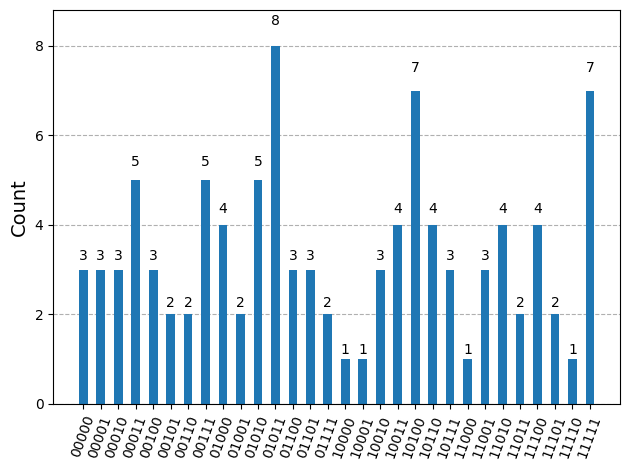

In [ ]:
# ==========================================================
#  CONFIGURAÇÂO (QFT MANUAL)
# ==========================================================
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
n = 5           # Número de qubits

# ==========================================================
# 1. OPERADOR QFT
# ==========================================================
qft_qc = QuantumCircuit(n, name="QFT")
# Loop do Circuito
for j in range(n):
# 1) Aplica a Hadamard
    qft_qc.h(j)
# 2) Aplica rotações de fase controladas
    for k in range(j + 1, n):
        angulo = np.pi / (2**(k - j))
        qft_qc.cp(angulo, k, j)
# 3) Aplicação das Portas SWAP
for i in range(n // 2):
    qft_qc.swap(i, n - i - 1)
qft_gate = qft_qc.to_gate()

# ==========================================================
# 2. ALGORITMO (APLICAÇÃO)
# ==========================================================
# Define os registros quânticos
qr = QuantumRegister(n, 'q')
# Define o registro clássico
cr = ClassicalRegister(n, 'c')
# Define o circuito quântico
qc = QuantumCircuit(qr, cr)

# --- Preparação do Estado de Entrada ---
# Use portas para definir o estado de entrada
qc.barrier()

# --- Aplicação da QFT ---
qc.append(qft_gate, qr)
qc.barrier()

# Final) Medição
qc.measure(qr, cr)

# Opcional) Mostrar o circuito
#display(qc.draw('mpl'))
# Mostra o circuito com o operador QFT exposto
#display(qc.decompose(reps=1).draw('mpl'))

# ==========================================================
# 3. EXECUÇÃO
# ==========================================================
from qiskit_aer import AerSimulator
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
from qiskit.visualization import plot_histogram

backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend)
isa_qc = pm.run(qc)
sampler = Sampler(backend)
job = sampler.run([isa_qc], shots=100)
result = job.result()
counts = result[0].data.c.get_counts()
plot_histogram(counts)

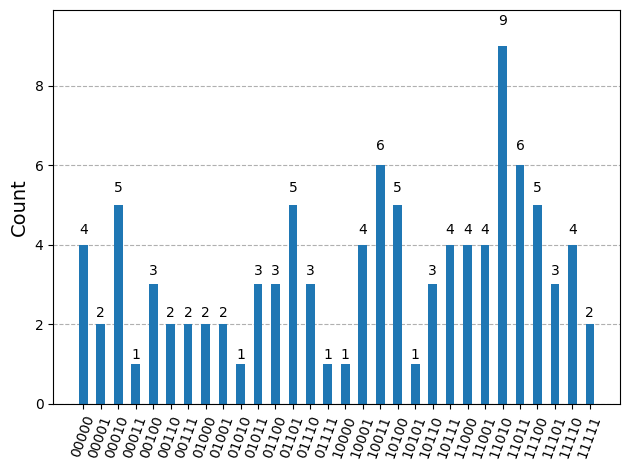

In [ ]:
# ==========================================================
#  Configurações (QFT NATIVO)
# ==========================================================
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
n = 5           # Número de qubits

# ==========================================================
# 1. ALGORITMO
# ==========================================================
# Define os registros quânticos
qr = QuantumRegister(n, 'q')
# Define o registro clássico
cr = ClassicalRegister(n, 'c')
# Define o circuito quântico
qc = QuantumCircuit(qr, cr)

# --- Preparação do Estado de Entrada ---
# Use portas para definir o estado de entrada
qc.barrier()

# --- Aplicação da QFT ---
from qiskit.circuit.library import QFTGate
# Define a porta QFT
qft_nativa = QFTGate(num_qubits=n)
# Adiciona ao circuito
qc.append(qft_nativa, qr)
qc.barrier()

# Final) Medição
qc.measure(qr, cr)

# Opcional) Mostrar o circuito
#display(qc.draw('mpl'))
# Mostra o circuito com o operador QFT exposto
#display(qc.decompose(reps=2).draw('mpl'))

# ==========================================================
# 3. EXECUÇÃO
# ==========================================================
from qiskit_aer import AerSimulator
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
from qiskit.visualization import plot_histogram

backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend)
isa_qc = pm.run(qc)
sampler = Sampler(backend)
job = sampler.run([isa_qc], shots=100)
result = job.result()
counts = result[0].data.c.get_counts()
plot_histogram(counts)

# **Algoritmo de Estimação de Fase**

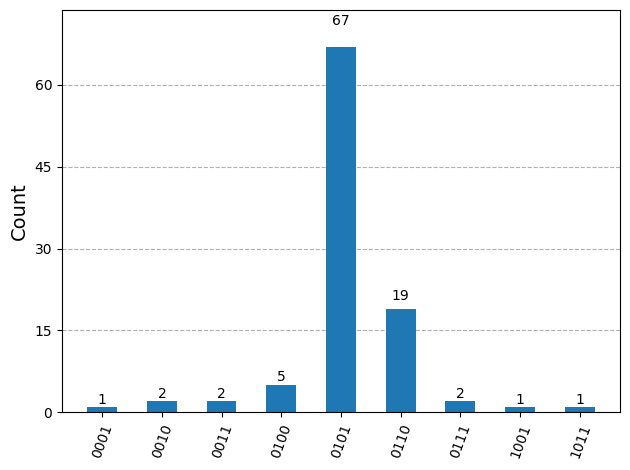

In [ ]:
# ==========================================================
# 1. CONFIGURAÇÕES
# ==========================================================
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

n_contagem = 4    # Qubits para precisão da fase
n_alvo = 1        # Qubits para o autovetor do operador U
fase_real = 1/3   # A fase que queremos estimar (ex: theta = 0.333...)

# ==========================================================
# 2. OPERADORES (QFT INVERSA)
# ==========================================================
from qiskit.circuit.library import QFTGate
# Define a porta QFT Inversa
qft_inversa = QFTGate(num_qubits=n_contagem).inverse()

# ==========================================================
# 3. ALGORITMO EFQ
# ==========================================================
qr_c = QuantumRegister(n_contagem, 'c') # Registro de contagem
qr_a = QuantumRegister(n_alvo, 'a')     # Registro alvo
cr = ClassicalRegister(n_contagem, 'res')
qc = QuantumCircuit(qr_c, qr_a, cr)

# A) Preparação do Autovetor (Estado |1>)
# Para estimar a fase de uma porta P, o alvo deve estar em |1>
qc.x(qr_a)
qc.barrier()

# B) Superposição no registro de contagem
qc.h(qr_c)
qc.barrier()

# C) Aplicação das Portas Controladas Unitárias (U^2^j)
for i in range(n_contagem):
    angulo_u = (2**i) * (2 * np.pi * fase_real)
    qc.cp(angulo_u, qr_c[i], qr_a[0])

qc.barrier()

# D) Aplicação da QFT Inversa
qc.append(qft_inversa, qr_c)
qc.barrier()

# E) Medição
qc.measure(qr_c, cr)

# Opcional) Mostrar o circuito
#display(qc.draw('mpl'))
# Mostra o circuito com o operador de Grover exposto
#display(qc.decompose(reps=1).draw('mpl'))

# ==========================================================
# 3. EXECUÇÃO
# ==========================================================
from qiskit_aer import AerSimulator
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
from qiskit.visualization import plot_histogram

backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend)
isa_qc = pm.run(qc)
sampler = Sampler(backend)
job = sampler.run([isa_qc], shots=100)
result = job.result()
counts = result[0].data.res.get_counts()
plot_histogram(counts)